In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import torch
from datasets import load_dataset
from torchvision.transforms import v2
import dotenv
import os

import ssl
from torch.utils.data import Dataset, random_split
from torchvision.datasets import MNIST as TorchMNIST
from torchvision.transforms import v2

import utils.cifar10_classification

In [32]:
dotenv.load_dotenv()
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cuda')

#### Preprocessing
1. `v2.ToImage()` converts PIL image objects (that live on RAM) into `torch.tensor()` without dividing the pixels values by `255` like the deprecated `v2.ToTensor()`
2. `v2.GrayScale()` changes the number of channels of the input to `num_output_channels` which is redundant for MNIST here
3. `v2.Resize((32,32))` changes the spatial dimensions (height and width) to $32 \times 32$ while keeping proportions
4. `v2.RandomCrop(32, padding=4)` crops random part of the images to enable better generalization of the model so it can recognize the same objects even when they  
\\ are shifted across the image. `padding=4` adds 4 pixes to the spatial dimensions making the images $40\times 40$ and then crop 32 by 32 square image (which `torchvision` assumes is square of 32 by 32 which is equivalent to `(32, 32)` ) 
5. `v2.RandomHorizontalFlip(p=0.5)` horizontally flop images with change of 50%
6. `v2.ToDtype(torch.float32, scale=True)` scale all pixels' values into `float32` (which uses 32 bits to represent decimals) and then `scale=True` divides all by \\ `255` before conversion
7. `v2.Normalize(mean=[0.1307, 0.1307, 0.1307], std=[0.3081, 0.3081, 0.3081])` subtract all pixels in all 3 dimensions by the global mean of the dataset and divide \\ by the std (z-score normalization) 


In [33]:

ssl._create_default_https_context = ssl._create_unverified_context

train_transform = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=3),  # Converts 1-channel MNIST to 3-channel pseudo-RGB
    v2.Resize((32, 32)),                  # Upscales from 28x28 to your original 32x32 size
    v2.RandomCrop(32, padding=4), 
    v2.RandomHorizontalFlip(p=0.5), 
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307, 0.1307, 0.1307], std=[0.3081, 0.3081, 0.3081]) 
])

eval_transform = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=3),
    v2.Resize((32, 32)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307, 0.1307, 0.1307], std=[0.3081, 0.3081, 0.3081])
])

# 3. Download and load via Torchvision (Fast ~11MB download total)
full_train_raw = TorchMNIST(root='./data', train=True, download=True)
full_test_raw = TorchMNIST(root='./data', train=False, download=True)

# 4. Slice the raw data to match your percentages (5% train, 2% test)
train_size = int(0.05 * len(full_train_raw))   # 5% of 60,000 = 3,000
test_size = int(0.02 * len(full_test_raw))     # 2% of 10,000 = 200

train_subset, _ = random_split(full_train_raw, [train_size, len(full_train_raw) - train_size])
test_subset, _ = random_split(full_test_raw, [test_size, len(full_test_raw) - test_size])

#### Dataset
the dataset class may inherit (although it is not necessary) from `torch.utils.data.Dataset` class and must define
`__init__()` for initializing and required info like metadata which runs ones to initialize the dataset
`__len__()` that returns the number of samples
`__getitem__(idx)` which returns the (input, output) pair in supervised learning and a sample in unsupervised learning and here is the where the transform is applied to samples as they are pulled from the dataset

### Dataloader
the dataloader takes the dataset and then processes it in way that makes it possible to iterate over and prepare the training samples 
and here `torch.utils.data.DataLoader` class is used for auto permutation, shuffling, defning the batch size and all other related parameters needed

In [34]:

class MNISTWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx] 
        img = self.transform(img)
        return img, label

dataset_train = MNISTWrapper(train_subset, train_transform)
print(f"Training dataset size: {len(dataset_train)}") # Outputs 3000

val_size = len(test_subset) // 2
test_slice_1, test_slice_2 = random_split(test_subset, [val_size, len(test_subset) - val_size])

dataset_val = MNISTWrapper(test_slice_1, eval_transform)
dataset_test = MNISTWrapper(test_slice_2, eval_transform)

print(f"Validation dataset size: {len(dataset_val)}") # Outputs 100
print(f"Testing dataset size: {len(dataset_test)}")   # Outputs 100


Training dataset size: 3000
Validation dataset size: 100
Testing dataset size: 100


##### `torch.utils.data.DataLoader`
This class is used to wrap datasets for training, validation, and testing loops.
* **Iterable Object:** It can be looped through directly:
  ```python
  for image, label in dataloader:
      pass
  ```
* **Tracking Batches:** To track the batch index or loop order, use `enumerate()`:
  ```python
  for batch_index, (image, label) in enumerate(dataloader):
      pass
  ```
* **Functionality:** `enumerate()` simply adds a sequential counter starting at `0`. It does not modify your data.


In [35]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=64, shuffle=True)

##### BasicNet
Consists of Conv2D $\rightarrow$ ReLU $\rightarrow$ Flatten $\rightarrow$ Linear

If $x$ is a single CIFAR10 sample such that $x \in \mathbb{R}^{3\times 32 \times 32}$

The layers are as follows:

* **Convolutional Layer:** 
  $$h_{i,j,k} = \text{ReLU}\left( \sum_{c=1}^{3} \sum_{n=1}^{11} \sum_{m=1}^{11} x_{i+n-1, \, j+m-1, \, c} \cdot w_{n,m,c,k} + b_k \right)$$
  Where the parameter tensor is $\Omega_1 \in \mathbb{R}^{3\times 96\times 11\times 11}$.
  The resulting feature map has the spatial dimensions $(32-11)+1 = 22$, yielding $h \in \mathbb{R}^{96 \times 22 \times 22}$.

* **Fully-Connected Linear Layer:** 
  $$\mathbf{y} = \Omega_2\mathbf{x_{\text{flat}}} + \mathbf{b}$$
  Where the weight matrix is $\Omega_2 \in \mathbb{R}^{10\times (96\times 22\times 22)}$, which simplifies to $\Omega_2 \in \mathbb{R}^{10 \times 46464}$.

* **Function Composition:**
  $$f_{\theta}(x) = \Omega_2 \text{Flatten}(\text{ReLU}(\Omega_1 * x)) + \mathbf{b}$$


In [ ]:
import architectures.BasicNet

bn = architectures.BasicNet.BasicNet()
utils.cifar10_classification.train(bn,train_loader, val_loader, epochs=50)
accuracry = utils.cifar10_classification.test(bn,test_loader)
print(f"Test accuracy: {accuracry:.2f}%")

Test accuracy: 0.66%


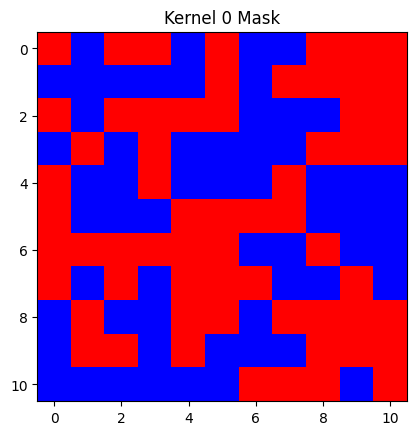

In [46]:

conv2d = bn.layers[0]  # Access the first convolutional layer


# Change the first index to pick your kernel (e.g., kernel index 42)
kernel_index = 0
selected_kernel = conv2d.weight[kernel_index, 0].detach().cpu().numpy()

# Apply your condition
plt.imshow((selected_kernel >= 0), cmap='bwr')
plt.title(f"Kernel {kernel_index} Mask")
plt.show()

